In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import os

stocks = {
    "RELIANCE": "RELIANCE.NS",
    "TCS": "TCS.NS",
    "INFY": "INFY.NS",
    "HDFCBANK": "HDFCBANK.NS",
    "ICICIBANK": "ICICIBANK.NS",
    "SBIN": "SBIN.NS",
    "ITC": "ITC.NS",
    "SUNPHARMA": "SUNPHARMA.NS",
    "TATAMOTORS": "TATAMOTORS.NS",
    "HCLTECH": "HCLTECH.NS"
}

os.makedirs("stock_data", exist_ok=True)

for name, ticker in stocks.items():
    data = yf.download(
        ticker,
        start="2016-01-01",
        end="2026-01-01",
        auto_adjust=False
    )

    data.to_csv(f"stock_data/{name}.csv")
    print(f"{name} downloaded: {len(data)} rows")

[*********************100%***********************]  1 of 1 completed


RELIANCE downloaded: 2470 rows


[*********************100%***********************]  1 of 1 completed


TCS downloaded: 2470 rows


[*********************100%***********************]  1 of 1 completed


...

SUNPHARMA downloaded: 2470 rows


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')


TATAMOTORS downloaded: 0 rows


[*********************100%***********************]  1 of 1 completed

HCLTECH downloaded: 2470 rows


In [3]:
import yfinance as yf
import os

data = yf.download(
    "MARUTI.NS",
    start="2016-01-01",
    end="2026-01-01",
    auto_adjust=False
)

data.to_csv("stock_data/MARUTI.csv")

print("MARUTI downloaded:", len(data), "rows")

[*********************100%***********************]  1 of 1 completed

MARUTI downloaded: 2470 rows


In [4]:
import pandas as pd

# Check one stock file
df = pd.read_csv("stock_data/RELIANCE.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

Shape: (2472, 7)

Columns:
Index(['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

First 5 rows:


,Price,Adj Close,Close,High,Low,Open,Volume
0,Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
1,Date,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-01,218.99749755859375,232.09193420410156,232.9033966064453,230.4575653076172,230.8232879638672,5416562
3,2016-01-04,214.6729736328125,227.5088348388672,231.7376251220703,225.5430145263672,229.72608947753906,30170947
4,2016-01-05,216.7974395751953,229.7603759765625,230.86900329589844,227.89743041992188,228.65174865722656,14946239


In [5]:
import pandas as pd
import os

stock_files = os.listdir("stock_data")

for file in stock_files:
    df = pd.read_csv("stock_data/" + file)

    print(
        file,
        "→ Rows:", len(df),
        "| Missing values:", df.isnull().sum().sum(),
        "| Duplicate rows:", df.duplicated().sum()
    )

TCS.csv → Rows: 2472 | Missing values: 6 | Duplicate rows: 0
ITC.csv → Rows: 2472 | Missing values: 6 | Duplicate rows: 0
SBIN.csv → Rows: 2472 | Missing values: 6 | Duplicate rows: 0
HCLTECH.csv → Rows: 2472 | Missing values: 6 | Duplicate rows: 0
TATAMOTORS.csv → Rows: 2 | Missing values: 6 | Duplicate rows: 0
ICICIBANK.csv → Rows: 2472 | Missing values: 6 | Duplicate rows: 0
HDFCBANK.csv → Rows: 2472 | Missing values: 6 | Duplicate rows: 0
MARUTI.csv → Rows: 2472 | Missing values: 6 | Duplicate rows: 0
RELIANCE.csv → Rows: 2472 | Missing values: 6 | Duplicate rows: 0
INFY.csv → Rows: 2472 | Missing values: 6 | Duplicate rows: 0
SUNPHARMA.csv → Rows: 2472 | Missing values: 6 | Duplicate rows: 0


In [7]:
import os

os.remove("stock_data/TATAMOTORS.csv")

print("TATAMOTORS.csv removed successfully")

TATAMOTORS.csv removed successfully


FileNotFoundError: [Errno 2] No such file or directory: 'stock_data/TATAMOTORS.csv'

In [8]:
print("TATAMOTORS.csv removed successfully")

TATAMOTORS.csv removed successfully


In [9]:
import os

print(os.listdir("stock_data"))

['TCS.csv', 'ITC.csv', 'SBIN.csv', 'HCLTECH.csv', 'ICICIBANK.csv', 'HDFCBANK.csv', 'MARUTI.csv', 'RELIANCE.csv', 'INFY.csv', 'SUNPHARMA.csv']


In [10]:
import pandas as pd
import os

stocks = [
    "RELIANCE",
    "TCS",
    "INFY",
    "HDFCBANK",
    "ICICIBANK",
    "SBIN",
    "ITC",
    "SUNPHARMA",
    "MARUTI",
    "HCLTECH"
]

cleaned_data = {}

for stock in stocks:
    file_path = f"stock_data/{stock}.csv"

    df = pd.read_csv(file_path)

    # The 'Date' column is incorrectly named 'Price' after reading the CSV.
    # Rename 'Price' to 'Date' to match the expected column name.
    df.rename(columns={"Price": "Date"}, inplace=True)

    # Keep Date and Close columns
    df = df[["Date", "Close"]]

    # Convert Date into proper date format
    df["Date"] = pd.to_datetime(df["Date"])

    # Convert Close price to numeric
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

    # Remove rows with missing values
    df = df.dropna()

    # Sort by date
    df = df.sort_values("Date")

    # Remove duplicate dates
    df = df.drop_duplicates(subset="Date")

    cleaned_data[stock] = df

    print(stock, "→", len(df), "clean rows")

print("\nCleaning completed!")

KeyError: "['Date'] not in index"

In [11]:
import pandas as pd

df = pd.read_csv("stock_data/RELIANCE.csv")

print("Column names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Column names:
['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

First 5 rows:


,Price,Adj Close,Close,High,Low,Open,Volume
0,Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
1,Date,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-01,218.99749755859375,232.09193420410156,232.9033966064453,230.4575653076172,230.8232879638672,5416562
3,2016-01-04,214.6729736328125,227.5088348388672,231.7376251220703,225.5430145263672,229.72608947753906,30170947
4,2016-01-05,216.7974395751953,229.7603759765625,230.86900329589844,227.89743041992188,228.65174865722656,14946239


In [12]:
import pandas as pd
import os

stocks = [
    "RELIANCE",
    "TCS",
    "INFY",
    "HDFCBANK",
    "ICICIBANK",
    "SBIN",
    "ITC",
    "SUNPHARMA",
    "MARUTI",
    "HCLTECH"
]

cleaned_data = {}

for stock in stocks:

    file_path = f"stock_data/{stock}.csv"

    # Read CSV
    df = pd.read_csv(file_path)

    # The first column contains the Date
    df = df.rename(columns={"Price": "Date"})

    # Remove the ticker row and keep actual data
    df = df.iloc[2:].copy()

    # Convert Date to datetime
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    # Convert Close price to numeric
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

    # Keep only Date and Close
    df = df[["Date", "Close"]]

    # Remove missing values
    df = df.dropna()

    # Sort by date
    df = df.sort_values("Date")

    # Remove duplicate dates
    df = df.drop_duplicates(subset="Date")

    # Store cleaned data
    cleaned_data[stock] = df

    print(stock, "→", len(df), "clean rows")

print("\n✅ All stocks cleaned successfully!")

RELIANCE → 2470 clean rows
TCS → 2470 clean rows
INFY → 2470 clean rows
HDFCBANK → 2470 clean rows
ICICIBANK → 2470 clean rows
SBIN → 2470 clean rows
ITC → 2470 clean rows
SUNPHARMA → 2470 clean rows
MARUTI → 2470 clean rows
HCLTECH → 2470 clean rows

✅ All stocks cleaned successfully!


In [13]:
import pandas as pd
import os

stocks = [
    "RELIANCE",
    "TCS",
    "INFY",
    "HDFCBANK",
    "ICICIBANK",
    "SBIN",
    "ITC",
    "SUNPHARMA",
    "MARUTI",
    "HCLTECH"
]

all_prices = []

for stock in stocks:
    file_path = f"stock_data/{stock}.csv"

    df = pd.read_csv(file_path)

    # Rename first column to Date
    df = df.rename(columns={"Price": "Date"})

    # Remove Yahoo Finance ticker row
    df = df.iloc[2:].copy()

    # Convert Date
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    # Convert Close to numeric
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

    # Keep only Date and Close
    df = df[["Date", "Close"]]

    # Remove invalid/missing data
    df = df.dropna()

    # Remove duplicate dates
    df = df.drop_duplicates(subset="Date")

    # Rename Close to stock name
    df = df.rename(columns={"Close": stock})

    all_prices.append(df)

# Combine all stocks using Date
prices = all_prices[0]

for df in all_prices[1:]:
    prices = pd.merge(prices, df, on="Date", how="inner")

# Sort by date
prices = prices.sort_values("Date")

# Reset index
prices = prices.reset_index(drop=True)

# Save combined dataset
prices.to_csv("combined_stock_prices.csv", index=False)

print("✅ Combined dataset created")
print("Rows:", len(prices))
print("Columns:", len(prices.columns))

display(prices.head())

✅ Combined dataset created
Rows: 2470
Columns: 11


,Date,RELIANCE,TCS,INFY,HDFCBANK,ICICIBANK,SBIN,ITC,SUNPHARMA,MARUTI,HCLTECH
0,2016-01-01,232.091934,1208.199951,552.625000,272.187500,239.090912,227.800003,210.236496,815.549988,4638.500000,422.924988
1,2016-01-04,227.508835,1184.800049,539.450012,267.625000,232.318176,220.699997,208.695831,799.099976,4580.649902,422.975006
2,2016-01-05,229.760376,1174.474976,537.025024,265.600006,233.363632,217.750000,208.535339,800.500000,4566.950195,421.399994
3,2016-01-06,235.943558,1190.800049,534.674988,266.774994,227.363632,216.850006,202.276398,791.950012,4480.799805,420.700012
4,2016-01-07,231.611908,1185.625000,525.400024,264.049988,224.318176,209.550003,198.745712,783.799988,4267.899902,412.524994


In [14]:
# Calculate daily percentage returns

returns = prices.copy()

returns.iloc[:, 1:] = returns.iloc[:, 1:].pct_change()

# Remove first row because it has no previous day
returns = returns.dropna()

# Save returns
returns.to_csv("daily_returns.csv", index=False)

print("✅ Daily returns calculated")
print("Rows:", len(returns))

display(returns.head())

✅ Daily returns calculated
Rows: 2469


,Date,RELIANCE,TCS,INFY,HDFCBANK,ICICIBANK,SBIN,ITC,SUNPHARMA,MARUTI,HCLTECH
1,2016-01-04,-0.019747,-0.019368,-0.023841,-0.016762,-0.028327,-0.031168,-0.007328,-0.020170,-0.012472,0.000118
2,2016-01-05,0.009896,-0.008715,-0.004495,-0.007567,0.004500,-0.013367,-0.000769,0.001752,-0.002991,-0.003724
3,2016-01-06,0.026911,0.013900,-0.004376,0.004424,-0.025711,-0.004133,-0.030014,-0.010681,-0.018864,-0.001661
4,2016-01-07,-0.018359,-0.004346,-0.017347,-0.010215,-0.013395,-0.033664,-0.017455,-0.010291,-0.047514,-0.019432
5,2016-01-08,0.012337,0.011112,0.011896,0.005823,-0.006890,-0.002863,0.013081,0.013205,-0.012453,0.004000


In [15]:
import numpy as np

feature_data = {}

for stock in stocks:

    df = prices[["Date", stock]].copy()

    # Daily return
    df["Return"] = df[stock].pct_change()

    # Previous day's return
    df["Return_Lag1"] = df["Return"].shift(1)

    # 5-day return
    df["Return_5D"] = df[stock].pct_change(5)

    # 10-day return
    df["Return_10D"] = df[stock].pct_change(10)

    # 20-day moving average
    df["MA_20"] = df[stock].rolling(20).mean()

    # Distance from moving average
    df["Price_vs_MA20"] = df[stock] / df["MA_20"] - 1

    # 20-day volatility
    df["Volatility_20D"] = df["Return"].rolling(20).std()

    # Target = next day's return
    df["Target"] = df["Return"].shift(-1)

    df = df.dropna()

    feature_data[stock] = df

print("✅ ML features created")

display(feature_data["RELIANCE"].head())

✅ ML features created


,Date,RELIANCE,Return,Return_Lag1,Return_5D,Return_10D,MA_20,Price_vs_MA20,Volatility_20D,Target
20,2016-02-01,235.509247,-0.004926,0.018193,0.026042,-0.040063,234.523482,0.004203,0.022870,-0.028293
21,2016-02-02,228.846054,-0.028293,-0.004926,-0.002789,-0.015440,234.590343,-0.024486,0.023352,-0.019727
22,2016-02-03,224.331528,-0.019727,-0.028293,-0.017962,-0.059601,234.318900,-0.042623,0.023666,-0.008508
23,2016-02-04,222.422867,-0.008508,-0.019727,-0.043121,-0.031357,233.642866,-0.048022,0.022782,-0.002210
24,2016-02-05,221.931412,-0.002210,-0.008508,-0.062295,-0.013513,233.158841,-0.048154,0.022482,-0.010145


In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

features = [
    "Return_Lag1",
    "Return_5D",
    "Return_10D",
    "Price_vs_MA20",
    "Volatility_20D"
]

models = {}
predictions = {}

for stock in stocks:

    df = feature_data[stock]

    X = df[features]
    y = df["Target"]

    # Time-based split: 80% training, 20% testing
    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    # Create model
    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    models[stock] = model
    predictions[stock] = pd.DataFrame({
        "Actual": y_test.values,
        "Predicted": y_pred
    })

    mae = mean_absolute_error(y_test, y_pred)

    print(f"{stock}: MAE = {mae:.6f}")

print("\n✅ ML training completed")

RELIANCE: MAE = 0.010247
TCS: MAE = 0.009952
INFY: MAE = 0.011862
HDFCBANK: MAE = 0.009273
ICICIBANK: MAE = 0.008783
SBIN: MAE = 0.010953
ITC: MAE = 0.008983
SUNPHARMA: MAE = 0.009886
MARUTI: MAE = 0.010535
HCLTECH: MAE = 0.012033

✅ ML training completed


In [17]:
# Expected annual returns
expected_returns = returns.iloc[:, 1:].mean() * 252

# Annualized covariance matrix
cov_matrix = returns.iloc[:, 1:].cov() * 252

# Annualized volatility
volatility = returns.iloc[:, 1:].std() * np.sqrt(252)

print("Expected Annual Returns:")
display(expected_returns)

print("\nAnnual Volatility:")
display(volatility)

print("\nCovariance Matrix:")
display(cov_matrix)

Expected Annual Returns:


,0
RELIANCE,0.231659
TCS,0.127237
INFY,0.144485
HDFCBANK,0.157236
ICICIBANK,0.222057
SBIN,0.202652
ITC,0.095744
SUNPHARMA,0.114282
MARUTI,0.169007
HCLTECH,0.171023



Annual Volatility:


,0
RELIANCE,0.270547
TCS,0.235130
INFY,0.263878
HDFCBANK,0.224774
ICICIBANK,0.303160
SBIN,0.328790
ITC,0.241762
SUNPHARMA,0.276133
MARUTI,0.276766
HCLTECH,0.259788



Covariance Matrix:


,RELIANCE,TCS,INFY,HDFCBANK,ICICIBANK,SBIN,ITC,SUNPHARMA,MARUTI,HCLTECH
RELIANCE,0.073196,0.017015,0.018025,0.023345,0.029415,0.032004,0.016279,0.019029,0.027698,0.019521
TCS,0.017015,0.055286,0.037487,0.012636,0.014521,0.013376,0.010040,0.010987,0.014624,0.035643
INFY,0.018025,0.037487,0.069632,0.015671,0.019163,0.016908,0.011102,0.014334,0.014768,0.041142
HDFCBANK,0.023345,0.012636,0.015671,0.050523,0.034534,0.030433,0.015438,0.011872,0.024301,0.013341
ICICIBANK,0.029415,0.014521,0.019163,0.034534,0.091906,0.064728,0.022110,0.018819,0.034283,0.015703
SBIN,0.032004,0.013376,0.016908,0.030433,0.064728,0.108103,0.025387,0.020665,0.033852,0.015250
ITC,0.016279,0.010040,0.011102,0.015438,0.022110,0.025387,0.058449,0.013602,0.017100,0.011270
SUNPHARMA,0.019029,0.010987,0.014334,0.011872,0.018819,0.020665,0.013602,0.076249,0.016888,0.013084
MARUTI,0.027698,0.014624,0.014768,0.024301,0.034283,0.033852,0.017100,0.016888,0.076599,0.016283
HCLTECH,0.019521,0.035643,0.041142,0.013341,0.015703,0.015250,0.011270,0.013084,0.016283,0.067490


In [18]:
from scipy.optimize import minimize

n = len(stocks)

# Starting with equal weights
initial_weights = np.ones(n) / n

# Portfolio return
def portfolio_return(weights):
    return np.dot(weights, expected_returns.values)

# Portfolio volatility
def portfolio_volatility(weights):
    return np.sqrt(
        np.dot(weights.T,
               np.dot(cov_matrix.values, weights))
    )

# Objective: minimize risk
def objective(weights):
    return portfolio_volatility(weights)

# Constraints
constraints = [
    {
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1
    }
]

# Each stock weight between 0 and 40%
bounds = [(0, 0.40) for _ in range(n)]

result = minimize(
    objective,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

optimal_weights = result.x

portfolio_result = pd.DataFrame({
    "Stock": stocks,
    "Weight": optimal_weights
})

portfolio_result["Weight (%)"] = portfolio_result["Weight"] * 100

print("✅ Portfolio optimization completed")

display(portfolio_result)

✅ Portfolio optimization completed


,Stock,Weight,Weight (%)
0,RELIANCE,5.831243e-02,5.831243e+00
1,TCS,1.800983e-01,1.800983e+01
2,INFY,4.396371e-02,4.396371e+00
3,HDFCBANK,2.135150e-01,2.135150e+01
4,ICICIBANK,4.794206e-19,4.794206e-17
5,SBIN,6.496743e-19,6.496743e-17
6,ITC,2.071511e-01,2.071511e+01
7,SUNPHARMA,1.507298e-01,1.507298e+01
8,MARUTI,6.994908e-02,6.994908e+00
9,HCLTECH,7.628056e-02,7.628056e+00


In [19]:
# Portfolio daily returns using optimized weights

stock_returns = returns[stocks]

portfolio_daily_returns = stock_returns.dot(optimal_weights)

# Cumulative portfolio value
cumulative_returns = (1 + portfolio_daily_returns).cumprod()

# Performance
total_return = cumulative_returns.iloc[-1] - 1

annual_return = (
    (1 + total_return) **
    (252 / len(portfolio_daily_returns))
) - 1

annual_volatility = portfolio_daily_returns.std() * np.sqrt(252)

sharpe_ratio = annual_return / annual_volatility

print("===== CLASSICAL PORTFOLIO RESULTS =====")
print(f"Total Return       : {total_return * 100:.2f}%")
print(f"Annual Return      : {annual_return * 100:.2f}%")
print(f"Annual Volatility  : {annual_volatility * 100:.2f}%")
print(f"Sharpe Ratio       : {sharpe_ratio:.3f}")

===== CLASSICAL PORTFOLIO RESULTS =====
Total Return       : 246.35%
Annual Return      : 13.52%
Annual Volatility  : 15.09%
Sharpe Ratio       : 0.896


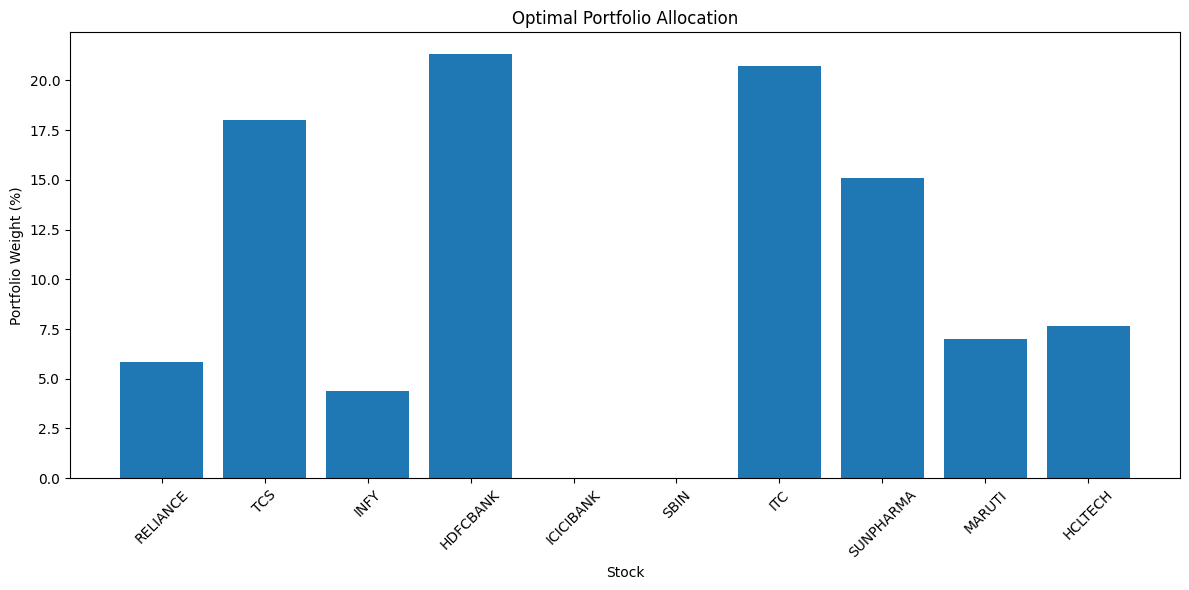

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    portfolio_result["Stock"],
    portfolio_result["Weight (%)"]
)

plt.title("Optimal Portfolio Allocation")
plt.xlabel("Stock")
plt.ylabel("Portfolio Weight (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

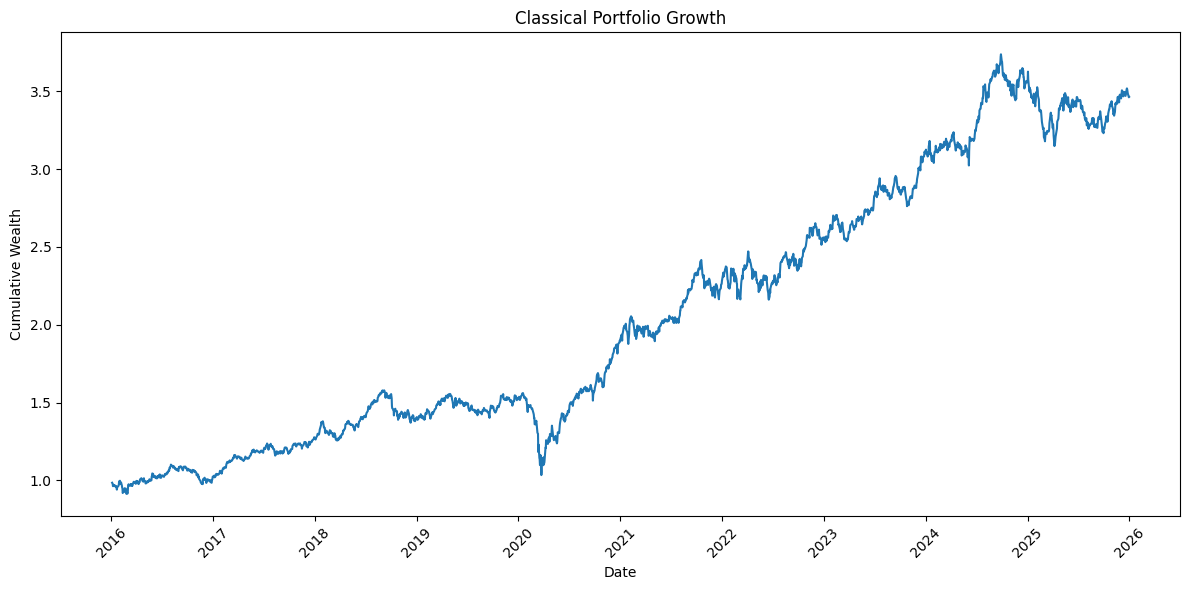

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    returns["Date"],
    cumulative_returns
)

plt.title("Classical Portfolio Growth")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

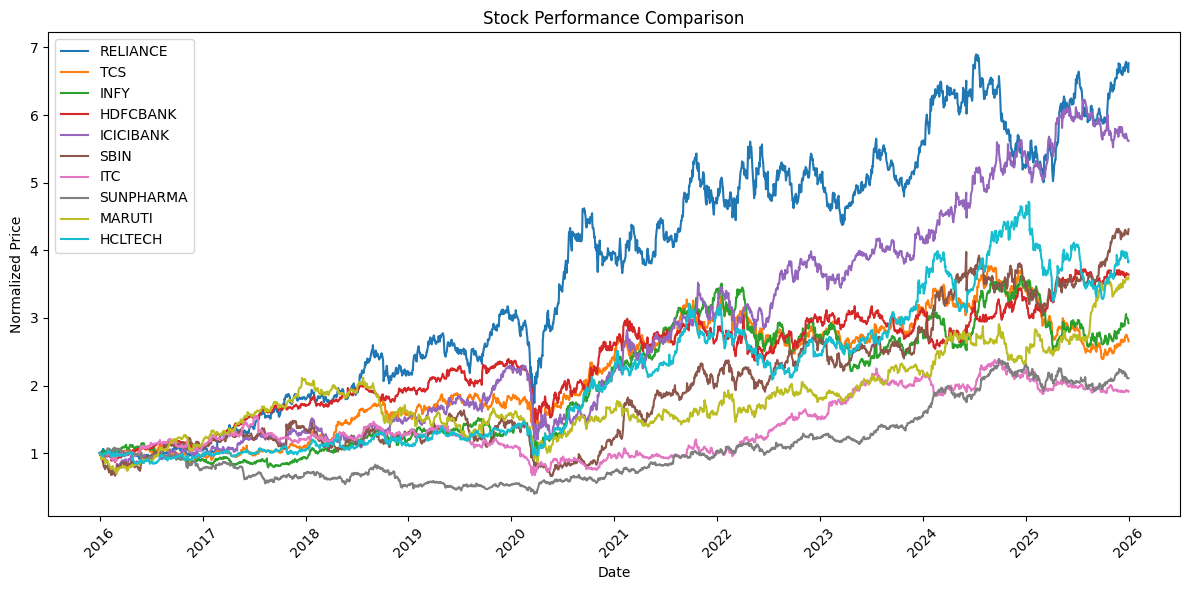

In [23]:
plt.figure(figsize=(12, 6))

for stock in stocks:
    normalized = prices[stock] / prices[stock].iloc[0]
    plt.plot(prices["Date"], normalized, label=stock)

plt.title("Stock Performance Comparison")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
print("Columns in returns:")
print(returns.columns.tolist())

print("\nFirst 5 rows:")
display(returns.head())

Columns in returns:
['Date', 'RELIANCE', 'TCS', 'INFY', 'HDFCBANK', 'ICICIBANK', 'SBIN', 'ITC', 'SUNPHARMA', 'MARUTI', 'HCLTECH']

First 5 rows:


,Date,RELIANCE,TCS,INFY,HDFCBANK,ICICIBANK,SBIN,ITC,SUNPHARMA,MARUTI,HCLTECH
1,2016-01-04,-0.019747,-0.019368,-0.023841,-0.016762,-0.028327,-0.031168,-0.007328,-0.020170,-0.012472,0.000118
2,2016-01-05,0.009896,-0.008715,-0.004495,-0.007567,0.004500,-0.013367,-0.000769,0.001752,-0.002991,-0.003724
3,2016-01-06,0.026911,0.013900,-0.004376,0.004424,-0.025711,-0.004133,-0.030014,-0.010681,-0.018864,-0.001661
4,2016-01-07,-0.018359,-0.004346,-0.017347,-0.010215,-0.013395,-0.033664,-0.017455,-0.010291,-0.047514,-0.019432
5,2016-01-08,0.012337,0.011112,0.011896,0.005823,-0.006890,-0.002863,0.013081,0.013205,-0.012453,0.004000


In [26]:
# ============================================
# CREATE ML DATASET FOR ALL 10 STOCKS
# ============================================

import pandas as pd
import numpy as np

# Copy our returns data
ml_data = returns.copy()

# List of stocks
stocks = [
    "RELIANCE",
    "TCS",
    "INFY",
    "HDFCBANK",
    "ICICIBANK",
    "SBIN",
    "ITC",
    "SUNPHARMA",
    "MARUTI",
    "HCLTECH"
]

# Create lag features and moving averages
for stock in stocks:

    # Previous day return
    ml_data[stock + "_Lag1"] = ml_data[stock].shift(1)

    # Return from 2 days ago
    ml_data[stock + "_Lag2"] = ml_data[stock].shift(2)

    # Return from 3 days ago
    ml_data[stock + "_Lag3"] = ml_data[stock].shift(3)

    # 5-day average return
    ml_data[stock + "_MA5"] = ml_data[stock].rolling(5).mean()

    # 10-day average return
    ml_data[stock + "_MA10"] = ml_data[stock].rolling(10).mean()

# Remove rows containing NaN values
ml_data = ml_data.dropna().reset_index(drop=True)

print("ML dataset created successfully!")
print("Number of rows:", len(ml_data))
print("Number of columns:", len(ml_data.columns))

display(ml_data.head())

ML dataset created successfully!
Number of rows: 2460
Number of columns: 61


,Date,RELIANCE,TCS,INFY,HDFCBANK,ICICIBANK,SBIN,ITC,SUNPHARMA,MARUTI,...,MARUTI_Lag1,MARUTI_Lag2,MARUTI_Lag3,MARUTI_MA5,MARUTI_MA10,HCLTECH_Lag1,HCLTECH_Lag2,HCLTECH_Lag3,HCLTECH_MA5,HCLTECH_MA10
0,2016-01-15,0.010973,-0.007767,0.006090,-0.007240,-0.047932,-0.059934,-0.010560,-0.005999,0.005908,...,-0.010020,0.005212,-0.000796,0.002796,-0.008031,0.002965,0.020184,-0.005525,0.002413,-0.000863
1,2016-01-18,-0.052595,0.007319,-0.007018,-0.015641,-0.006015,-0.017906,0.004779,-0.002731,-0.008693,...,0.005908,-0.010020,0.005212,-0.001678,-0.007653,0.011100,0.002965,0.020184,0.006771,-0.000362
2,2016-01-19,0.026307,0.000724,0.006847,0.009699,0.025325,0.010773,-0.004280,0.011402,-0.008982,...,-0.008693,0.005908,-0.010020,-0.003315,-0.008252,0.005131,0.011100,0.002965,0.006902,-0.000477
3,2016-01-20,-0.037419,0.000351,-0.016145,-0.016895,-0.019016,-0.050834,-0.016239,-0.001638,-0.033157,...,-0.008982,-0.008693,0.005908,-0.010989,-0.009682,-0.004867,0.005131,0.011100,0.003736,0.000125
4,2016-01-21,-0.020258,-0.011228,0.014091,0.004616,0.008467,0.011230,-0.008254,-0.024539,-0.041205,...,-0.033157,-0.008982,-0.008693,-0.017226,-0.009051,0.004354,-0.004867,0.005131,0.001564,0.001278


In [27]:
# ============================================
# TRAIN RANDOM FOREST ML MODELS
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

predictions = {}
model_results = {}

# Features used by the ML model
feature_suffixes = [
    "_Lag1",
    "_Lag2",
    "_Lag3",
    "_MA5",
    "_MA10"
]

for stock in stocks:

    # Create feature column names
    features = [stock + suffix for suffix in feature_suffixes]

    # X = input features
    X = ml_data[features]

    # y = today's return
    # We will shift it so that the model learns from previous information
    y = ml_data[stock]

    # Time-series split
    split = int(len(ml_data) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    # Create Random Forest model
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    # Train model
    model.fit(X_train, y_train)

    # Predict test data
    y_pred = model.predict(X_test)

    # Calculate errors
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    model_results[stock] = {
        "MAE": mae,
        "RMSE": rmse
    }

    # Prediction for the latest available data
    latest_data = X.iloc[[-1]]
    future_prediction = model.predict(latest_data)[0]

    predictions[stock] = future_prediction


print("============================================")
print("ML TRAINING COMPLETED")
print("============================================")

print("\nPredicted Returns:")

for stock, prediction in predictions.items():
    print(f"{stock:10s} : {prediction:.6f}")

print("\nModel Performance:")

for stock, result in model_results.items():
    print(
        f"{stock:10s} | "
        f"MAE = {result['MAE']:.6f} | "
        f"RMSE = {result['RMSE']:.6f}"
    )

ML TRAINING COMPLETED

Predicted Returns:
RELIANCE   : 0.003032
TCS        : -0.004371
INFY       : -0.005888
HDFCBANK   : 0.001842
ICICIBANK  : -0.001168
SBIN       : 0.000141
ITC        : 0.001959
SUNPHARMA  : -0.006972
MARUTI     : 0.000216
HCLTECH    : -0.001922

Model Performance:
RELIANCE   | MAE = 0.007683 | RMSE = 0.010303
TCS        | MAE = 0.007677 | RMSE = 0.010140
INFY       | MAE = 0.009241 | RMSE = 0.012168
HDFCBANK   | MAE = 0.006742 | RMSE = 0.009452
ICICIBANK  | MAE = 0.006649 | RMSE = 0.008943
SBIN       | MAE = 0.008264 | RMSE = 0.012064
ITC        | MAE = 0.006668 | RMSE = 0.008900
SUNPHARMA  | MAE = 0.007460 | RMSE = 0.009701
MARUTI     | MAE = 0.007762 | RMSE = 0.010417
HCLTECH    | MAE = 0.008769 | RMSE = 0.011768


In [28]:
# ============================================
# PORTFOLIO RISK ANALYSIS
# ============================================

import numpy as np
import pandas as pd

# Calculate annualized return
annual_returns = returns[stocks].mean() * 252

# Calculate annualized volatility (risk)
annual_risk = returns[stocks].std() * np.sqrt(252)

# Create risk-return table
risk_return = pd.DataFrame({
    "Expected Annual Return": annual_returns,
    "Annual Risk (Volatility)": annual_risk
})

# Add ML predicted return
risk_return["ML Predicted Return"] = pd.Series(predictions)

# Display results
print("RISK - RETURN ANALYSIS")
print("=" * 60)

display(risk_return.sort_values(
    "ML Predicted Return",
    ascending=False
))

RISK - RETURN ANALYSIS


,Expected Annual Return,Annual Risk (Volatility),ML Predicted Return
RELIANCE,0.231659,0.270547,0.003032
ITC,0.095744,0.241762,0.001959
HDFCBANK,0.157236,0.224774,0.001842
MARUTI,0.169007,0.276766,0.000216
SBIN,0.202652,0.328790,0.000141
ICICIBANK,0.222057,0.303160,-0.001168
HCLTECH,0.171023,0.259788,-0.001922
TCS,0.127237,0.235130,-0.004371
INFY,0.144485,0.263878,-0.005888
SUNPHARMA,0.114282,0.276133,-0.006972


In [29]:
# ============================================
# STOCK CORRELATION MATRIX
# ============================================

correlation_matrix = returns[stocks].corr()

print("STOCK RETURN CORRELATION")
print("=" * 60)

display(correlation_matrix.round(2))

STOCK RETURN CORRELATION


,RELIANCE,TCS,INFY,HDFCBANK,ICICIBANK,SBIN,ITC,SUNPHARMA,MARUTI,HCLTECH
RELIANCE,1.00,0.27,0.25,0.38,0.36,0.36,0.25,0.25,0.37,0.28
TCS,0.27,1.00,0.60,0.24,0.20,0.17,0.18,0.17,0.22,0.58
INFY,0.25,0.60,1.00,0.26,0.24,0.19,0.17,0.20,0.20,0.60
HDFCBANK,0.38,0.24,0.26,1.00,0.51,0.41,0.28,0.19,0.39,0.23
ICICIBANK,0.36,0.20,0.24,0.51,1.00,0.65,0.30,0.22,0.41,0.20
SBIN,0.36,0.17,0.19,0.41,0.65,1.00,0.32,0.23,0.37,0.18
ITC,0.25,0.18,0.17,0.28,0.30,0.32,1.00,0.20,0.26,0.18
SUNPHARMA,0.25,0.17,0.20,0.19,0.22,0.23,0.20,1.00,0.22,0.18
MARUTI,0.37,0.22,0.20,0.39,0.41,0.37,0.26,0.22,1.00,0.23
HCLTECH,0.28,0.58,0.60,0.23,0.20,0.18,0.18,0.18,0.23,1.00


In [30]:
# ==========================================
# STEP: Calculate Portfolio Statistics
# ==========================================

import numpy as np
import pandas as pd

# Remove Date column for calculations
returns_only = returns.drop(columns=["Date"])

# Expected annual returns
expected_returns = returns_only.mean() * 252

# Annualized covariance matrix
cov_matrix = returns_only.cov() * 252

print("Expected Annual Returns:")
display(expected_returns)

print("\nAnnualized Covariance Matrix:")
display(cov_matrix)

Expected Annual Returns:


,0
RELIANCE,0.231659
TCS,0.127237
INFY,0.144485
HDFCBANK,0.157236
ICICIBANK,0.222057
SBIN,0.202652
ITC,0.095744
SUNPHARMA,0.114282
MARUTI,0.169007
HCLTECH,0.171023



Annualized Covariance Matrix:


,RELIANCE,TCS,INFY,HDFCBANK,ICICIBANK,SBIN,ITC,SUNPHARMA,MARUTI,HCLTECH
RELIANCE,0.073196,0.017015,0.018025,0.023345,0.029415,0.032004,0.016279,0.019029,0.027698,0.019521
TCS,0.017015,0.055286,0.037487,0.012636,0.014521,0.013376,0.010040,0.010987,0.014624,0.035643
INFY,0.018025,0.037487,0.069632,0.015671,0.019163,0.016908,0.011102,0.014334,0.014768,0.041142
HDFCBANK,0.023345,0.012636,0.015671,0.050523,0.034534,0.030433,0.015438,0.011872,0.024301,0.013341
ICICIBANK,0.029415,0.014521,0.019163,0.034534,0.091906,0.064728,0.022110,0.018819,0.034283,0.015703
SBIN,0.032004,0.013376,0.016908,0.030433,0.064728,0.108103,0.025387,0.020665,0.033852,0.015250
ITC,0.016279,0.010040,0.011102,0.015438,0.022110,0.025387,0.058449,0.013602,0.017100,0.011270
SUNPHARMA,0.019029,0.010987,0.014334,0.011872,0.018819,0.020665,0.013602,0.076249,0.016888,0.013084
MARUTI,0.027698,0.014624,0.014768,0.024301,0.034283,0.033852,0.017100,0.016888,0.076599,0.016283
HCLTECH,0.019521,0.035643,0.041142,0.013341,0.015703,0.015250,0.011270,0.013084,0.016283,0.067490


In [32]:
# Step 6: Train-Test Split

from sklearn.model_selection import train_test_split

# Define the stock for which to create the train-test split
selected_stock = "RELIANCE"

# Features for the selected stock
features = [
    f"{selected_stock}_Lag1",
    f"{selected_stock}_Lag2",
    f"{selected_stock}_Lag3",
    f"{selected_stock}_MA5",
    f"{selected_stock}_MA10"
]

# Target for the selected stock (its daily return)
X = ml_data[features]
y = ml_data[selected_stock]

# Chronological split - 80% training, 20% testing
split_index = int(len(ml_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Train-test split for {selected_stock}:")
print("Training data points:", len(X_train))
print("Testing data points:", len(X_test))

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

KeyError: "None of [Index(['Return_Lag', 'MA_5', 'MA_10'], dtype='object')] are in the [columns]"

In [33]:
# Step 6A: Create features for the model

# Calculate equal-weighted portfolio return
ml_data["Return"] = returns.drop(columns=["Date"]).mean(axis=1)

# Create features
ml_data["Return_Lag"] = ml_data["Return"].shift(1)
ml_data["MA_5"] = ml_data["Return"].rolling(5).mean()
ml_data["MA_10"] = ml_data["Return"].rolling(10).mean()

# Target = next day's return
ml_data["Target"] = ml_data["Return"].shift(-1)

# Remove missing values
ml_data = ml_data.dropna().reset_index(drop=True)

print("Features created successfully!")
print(ml_data.columns.tolist())
print("Rows:", len(ml_data))
display(ml_data.head())

Features created successfully!
['Date', 'RELIANCE', 'TCS', 'INFY', 'HDFCBANK', 'ICICIBANK', 'SBIN', 'ITC', 'SUNPHARMA', 'MARUTI', 'HCLTECH', 'RELIANCE_Lag1', 'RELIANCE_Lag2', 'RELIANCE_Lag3', 'RELIANCE_MA5', 'RELIANCE_MA10', 'TCS_Lag1', 'TCS_Lag2', 'TCS_Lag3', 'TCS_MA5', 'TCS_MA10', 'INFY_Lag1', 'INFY_Lag2', 'INFY_Lag3', 'INFY_MA5', 'INFY_MA10', 'HDFCBANK_Lag1', 'HDFCBANK_Lag2', 'HDFCBANK_Lag3', 'HDFCBANK_MA5', 'HDFCBANK_MA10', 'ICICIBANK_Lag1', 'ICICIBANK_Lag2', 'ICICIBANK_Lag3', 'ICICIBANK_MA5', 'ICICIBANK_MA10', 'SBIN_Lag1', 'SBIN_Lag2', 'SBIN_Lag3', 'SBIN_MA5', 'SBIN_MA10', 'ITC_Lag1', 'ITC_Lag2', 'ITC_Lag3', 'ITC_MA5', 'ITC_MA10', 'SUNPHARMA_Lag1', 'SUNPHARMA_Lag2', 'SUNPHARMA_Lag3', 'SUNPHARMA_MA5', 'SUNPHARMA_MA10', 'MARUTI_Lag1', 'MARUTI_Lag2', 'MARUTI_Lag3', 'MARUTI_MA5', 'MARUTI_MA10', 'HCLTECH_Lag1', 'HCLTECH_Lag2', 'HCLTECH_Lag3', 'HCLTECH_MA5', 'HCLTECH_MA10', 'Return', 'Return_Lag', 'MA_5', 'MA_10', 'Target']
Rows: 2449


,Date,RELIANCE,TCS,INFY,HDFCBANK,ICICIBANK,SBIN,ITC,SUNPHARMA,MARUTI,...,HCLTECH_Lag1,HCLTECH_Lag2,HCLTECH_Lag3,HCLTECH_MA5,HCLTECH_MA10,Return,Return_Lag,MA_5,MA_10,Target
0,2016-02-01,-0.004926,0.004767,0.007254,0.009430,-0.056268,-0.039744,0.014210,-0.000745,-0.036036,...,0.025163,0.010167,-0.003219,0.009652,0.004977,-0.010536,-0.002639,-0.003007,-0.005479,-0.009337
1,2016-02-02,-0.028293,-0.001914,0.001875,-0.005614,-0.031308,-0.019392,-0.001540,-0.042589,-0.018565,...,0.016806,0.025163,0.010167,0.008045,0.003595,-0.009337,-0.010536,-0.003763,-0.004622,0.007295
2,2016-02-03,-0.019727,0.007589,-0.015184,-0.009442,-0.030181,-0.019776,-0.007093,-0.000299,-0.012026,...,-0.008690,0.016806,0.025163,0.003979,0.001727,0.007295,-0.009337,-0.000821,-0.003638,-0.018664
3,2016-02-04,-0.008508,0.001552,0.019046,0.005125,-0.000490,-0.019271,-0.000466,0.000838,-0.008803,...,-0.023549,-0.008690,0.016806,0.005525,0.003081,-0.018664,0.007295,-0.006776,-0.005002,-0.007498
4,2016-02-05,-0.002210,0.000785,-0.004281,0.005766,0.026722,0.032852,0.006681,0.026269,-0.018776,...,0.017897,-0.023549,-0.008690,0.001023,0.004136,-0.007498,-0.018664,-0.007748,-0.003832,0.021277


In [34]:
# Step 6B: Train-Test Split

features = ["Return_Lag", "MA_5", "MA_10"]

X = ml_data[features]
y = ml_data["Target"]

split_index = int(len(ml_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", len(X_train))
print("Testing data:", len(X_test))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Training data: 1959
Testing data: 490
X_train shape: (1959, 3)
X_test shape: (490, 3)


In [35]:
# Step 7: Train Random Forest model

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Create the model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model trained successfully!")
print("RMSE:", rmse)
print("R² Score:", r2)

Model trained successfully!
RMSE: 0.008536150204555329
R² Score: -0.19265216024924348


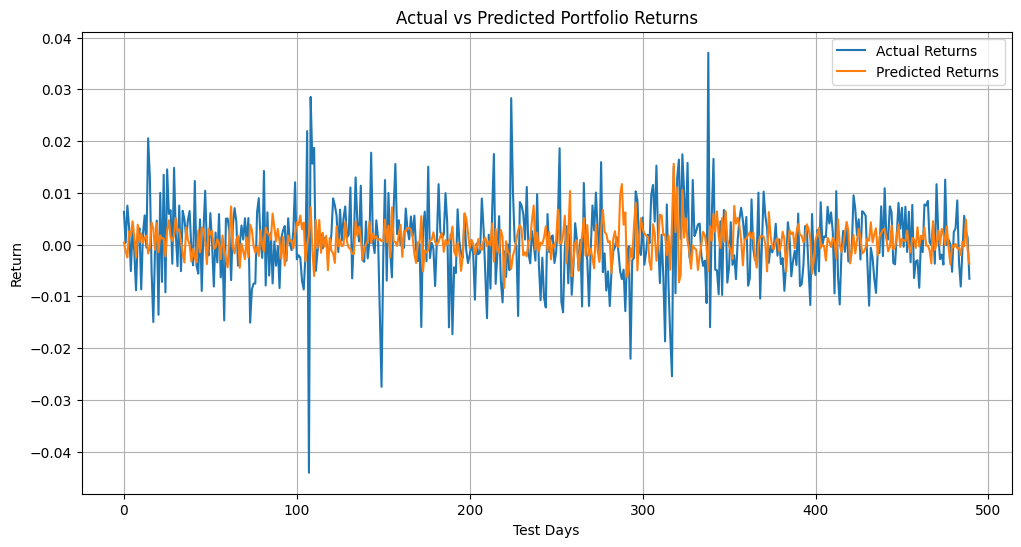

In [36]:
# Step 8: Compare actual and predicted returns

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(y_test.values, label="Actual Returns")
plt.plot(y_pred, label="Predicted Returns")

plt.title("Actual vs Predicted Portfolio Returns")
plt.xlabel("Test Days")
plt.ylabel("Return")

plt.legend()
plt.grid(True)
plt.show()

In [37]:
# Step 9: Calculate portfolio performance

results = pd.DataFrame({
    "Actual_Return": y_test.values,
    "Predicted_Return": y_pred
})

# Strategy return: invest when predicted return is positive
results["Strategy_Return"] = (
    results["Predicted_Return"].apply(lambda x: x if x > 0 else 0)
)

# Cumulative returns
results["Cumulative_Actual"] = (
    (1 + results["Actual_Return"]).cumprod() - 1
)

results["Cumulative_Strategy"] = (
    (1 + results["Strategy_Return"]).cumprod() - 1
)

print("Portfolio performance calculated successfully!")
print("Final Actual Return:",
      results["Cumulative_Actual"].iloc[-1])
print("Final Strategy Return:",
      results["Cumulative_Strategy"].iloc[-1])

display(results.head())

Portfolio performance calculated successfully!
Final Actual Return: 0.23958257745391376
Final Strategy Return: 1.1149020959530964


,Actual_Return,Predicted_Return,Strategy_Return,Cumulative_Actual,Cumulative_Strategy
0,0.006332,0.000382,0.000382,0.006332,0.000382
1,0.000326,-0.001235,0.000000,0.006660,0.000382
2,0.007523,-0.002490,0.000000,0.014233,0.000382
3,0.003229,0.002555,0.002555,0.017509,0.002938
4,-0.005128,0.001659,0.001659,0.012291,0.004601


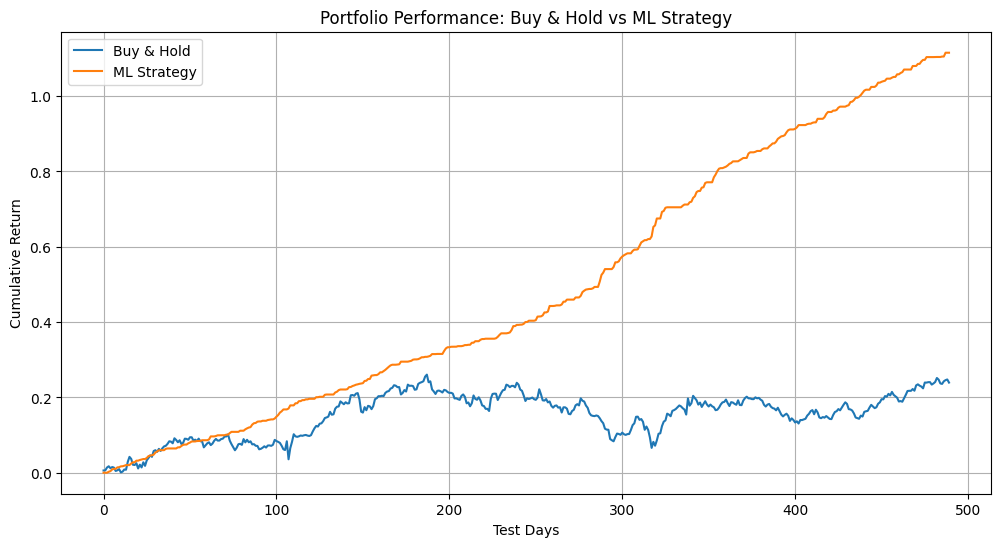

In [38]:
# Step 10: Plot portfolio performance

plt.figure(figsize=(12, 6))

plt.plot(
    results["Cumulative_Actual"],
    label="Buy & Hold"
)

plt.plot(
    results["Cumulative_Strategy"],
    label="ML Strategy"
)

plt.title("Portfolio Performance: Buy & Hold vs ML Strategy")
plt.xlabel("Test Days")
plt.ylabel("Cumulative Return")

plt.legend()
plt.grid(True)
plt.show()

In [39]:
# Step 11: Classical Portfolio Optimization

from scipy.optimize import minimize
import numpy as np
import pandas as pd

# Stock return data
stock_returns = returns[stocks]

# Expected annual returns
expected_returns = stock_returns.mean() * 252

# Annual covariance matrix
cov_matrix = stock_returns.cov() * 252

# Number of stocks
n_stocks = len(stocks)

# Portfolio return
def portfolio_return(weights):
    return np.dot(weights, expected_returns.values)

# Portfolio risk
def portfolio_risk(weights):
    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix.values, weights)
        )
    )

# Objective: minimize risk
def objective(weights):
    return portfolio_risk(weights)

# All weights must add to 100%
constraints = [
    {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }
]

# Each stock can have maximum 40%
bounds = [(0, 0.40) for _ in range(n_stocks)]

# Start with equal investment
initial_weights = np.ones(n_stocks) / n_stocks

# Run optimizer
optimization_result = minimize(
    objective,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

# Get optimal weights
optimal_weights = optimization_result.x

# Create result table
portfolio_weights = pd.DataFrame({
    "Stock": stocks,
    "Weight": optimal_weights,
    "Weight (%)": optimal_weights * 100
})

print("CLASSICAL PORTFOLIO OPTIMIZATION")
print("=" * 50)

display(portfolio_weights)

print("Total Weight:",
      optimal_weights.sum() * 100, "%")

print("Expected Annual Return:",
      portfolio_return(optimal_weights) * 100, "%")

print("Annual Portfolio Risk:",
      portfolio_risk(optimal_weights) * 100, "%")

CLASSICAL PORTFOLIO OPTIMIZATION


,Stock,Weight,Weight (%)
0,RELIANCE,5.831243e-02,5.831243e+00
1,TCS,1.800983e-01,1.800983e+01
2,INFY,4.396371e-02,4.396371e+00
3,HDFCBANK,2.135150e-01,2.135150e+01
4,ICICIBANK,4.794206e-19,4.794206e-17
5,SBIN,6.496743e-19,6.496743e-17
6,ITC,2.071511e-01,2.071511e+01
7,SUNPHARMA,1.507298e-01,1.507298e+01
8,MARUTI,6.994908e-02,6.994908e+00
9,HCLTECH,7.628056e-02,7.628056e+00


Total Weight: 100.0 %
Expected Annual Return: 13.827489099096757 %
Annual Portfolio Risk: 15.093248397080162 %


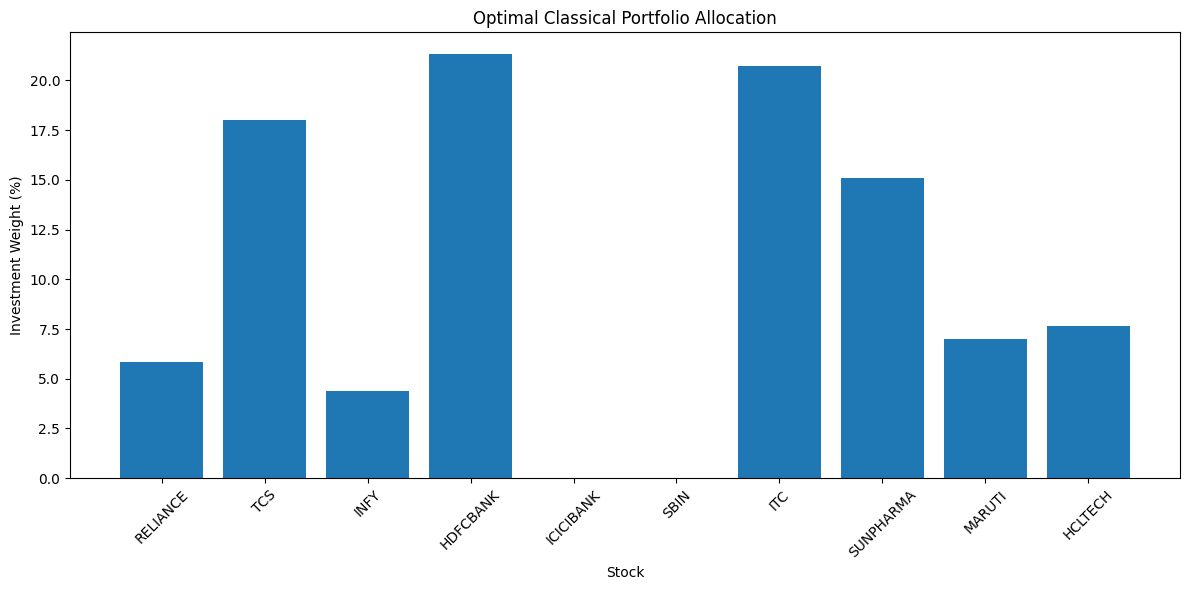

In [40]:
# Step 12: Visualize optimal portfolio allocation

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    portfolio_weights["Stock"],
    portfolio_weights["Weight (%)"]
)

plt.title("Optimal Classical Portfolio Allocation")
plt.xlabel("Stock")
plt.ylabel("Investment Weight (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
# Step 13: Final Portfolio Performance

# Daily portfolio returns
portfolio_daily_returns = stock_returns.dot(optimal_weights)

# Annual return
portfolio_annual_return = portfolio_daily_returns.mean() * 252

# Annual risk (volatility)
portfolio_annual_risk = portfolio_daily_returns.std() * np.sqrt(252)

# Sharpe Ratio
risk_free_rate = 0.06

sharpe_ratio = (
    portfolio_annual_return - risk_free_rate
) / portfolio_annual_risk

print("======================================")
print("CLASSICAL PORTFOLIO PERFORMANCE")
print("======================================")

print(f"Annual Return     : {portfolio_annual_return * 100:.2f}%")
print(f"Annual Risk       : {portfolio_annual_risk * 100:.2f}%")
print(f"Sharpe Ratio      : {sharpe_ratio:.3f}")

CLASSICAL PORTFOLIO PERFORMANCE
Annual Return     : 13.83%
Annual Risk       : 15.09%
Sharpe Ratio      : 0.519


In [42]:
# Step 14: Backtest the optimized portfolio

# Daily portfolio returns
backtest_returns = stock_returns.dot(optimal_weights)

# Cumulative portfolio value
portfolio_value = (1 + backtest_returns).cumprod()

# Maximum drawdown
running_max = portfolio_value.cummax()
drawdown = (portfolio_value - running_max) / running_max
max_drawdown = drawdown.min()

# Total return
total_return = portfolio_value.iloc[-1] - 1

print("======================================")
print("CLASSICAL PORTFOLIO BACKTEST")
print("======================================")

print(f"Total Return    : {total_return * 100:.2f}%")
print(f"Maximum Drawdown: {max_drawdown * 100:.2f}%")
print(f"Final Value     : ₹{portfolio_value.iloc[-1]:.2f}")

CLASSICAL PORTFOLIO BACKTEST
Total Return    : 246.35%
Maximum Drawdown: -34.49%
Final Value     : ₹3.46
